# Detección de Anomalías — Calidad del Aire Madrid (NO y O3)

Este notebook implementa el sistema de detección de anomalías operacionales (fallos de sensor) y ambientales (outliers) para los contaminantes Monóxido de nitrógeno (NO, magnitud 7) y Ozono (O3, magnitud 14) en Madrid (2018-2026).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

# Estilo global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 90
plt.rcParams['figure.figsize'] = (12, 5)

# Cargar librerías internas del proyecto
sys.path.append('../src/etl')
from limpiar_datos import limpiar_datos_csv

## 1. Carga y Procesamiento de Datos

Cargamos el dataset histórico en bruto utilizando el script de limpieza del ETL, convirtiéndolo a formato largo, y luego filtramos para conservar únicamente los contaminantes de interés: NO y O3.

In [2]:
# Definición de rutas
PATH_DATASET = "../data/raw/datos_completos_2018_2026.csv"
PATH_ESTACIONES = "../data/raw/estaciones-de-control.csv"

# Cargar y limpiar usando el módulo del ETL
print("Cargando y procesando dataset histórico...")
df_largo = limpiar_datos_csv(PATH_DATASET, PATH_ESTACIONES)

# Filtrar solo para NO (magnitud 7) y O3 (magnitud 14)
df_largo = df_largo[df_largo['magnitud'].isin([7, 14])].copy()

print(f"Dimensiones del dataset procesado (formato largo): {df_largo.shape}")
print(f"Número de estaciones únicas: {df_largo['nombre_estacion'].nunique()}")
df_largo.head()

Cargando y procesando dataset histórico...
Dimensiones del dataset procesado (formato largo): (2705784, 16)
Número de estaciones únicas: 24


,provincia,municipio,estacion,magnitud,contaminante,punto_muestreo,nombre_estacion,ano,mes,dia,hora,valor,validacion,fecha,dia_semana,es_fin_semana
12,28,79,16,7,NO,28079016_7_8,Arturo Soria,2018,1,1,0,1.00,V,2018-01-01 00:00:00,0,False
15,28,79,16,14,O3,28079016_14_6,Arturo Soria,2018,1,1,0,70.83,V,2018-01-01 00:00:00,0,False
320141,28,79,16,7,NO,28079016_7_8,Arturo Soria,2018,1,1,1,2.00,V,2018-01-01 01:00:00,0,False
320144,28,79,16,14,O3,28079016_14_6,Arturo Soria,2018,1,1,1,59.47,V,2018-01-01 01:00:00,0,False
640270,28,79,16,7,NO,28079016_7_8,Arturo Soria,2018,1,1,2,4.00,V,2018-01-01 02:00:00,0,False


## 2. Detección de Anomalías Operativas (Sensor)

Las anomalías operativas se deben a fallos físicos en los sensores. Dos tipos comunes son:
1. **Sensor congelado (Flatlines)**: Lecturas constantes idénticas durante un período prolongado (por ejemplo, más de 6 horas seguidas en un contaminante dinámico).
2. **Lecturas incoherentes**: Valores extremadamente negativos (excepto flags específicos conocidos).

Definimos reglas sencillas para etiquetar estas anomalías antes de pasar al modelado ambiental.

In [3]:
# 1. Identificar flatlines (valores repetidos de forma consecutiva)
# Creamos una columna auxiliar que calcula la diferencia consecutiva por Estación y Contaminante
df_largo = df_largo.sort_values(['nombre_estacion', 'contaminante', 'fecha'])

df_largo['val_diff'] = df_largo.groupby(['nombre_estacion', 'contaminante'])['valor'].diff()

# Encontrar secuencias de 0s consecutivos en la diferencia (valores idénticos)
# Usamos una ventana de tamaño 6 (6 horas consecutivas con el mismo valor)
df_largo['is_zero_diff'] = (df_largo['val_diff'] == 0).astype(int)
df_largo['consecutive_zeros'] = df_largo.groupby(['nombre_estacion', 'contaminante'])['is_zero_diff'].rolling(window=6, min_periods=6).sum().reset_index(level=[0, 1], drop=True)

# Si la suma de la ventana de 6 es 5 (es decir, 6 mediciones idénticas consecutivas), marcamos como anomalía operativa
df_largo['anomalia_operativa'] = (df_largo['consecutive_zeros'] >= 5) | (df_largo['valor'] < 0)

print(f"Total mediciones analizadas: {df_largo.shape[0]:,}")
print(f"Anomalías operativas detectadas (valores constantes >=6h o negativos): {df_largo['anomalia_operativa'].sum():,} ({df_largo['anomalia_operativa'].mean()*100:.3f}%)")

Total mediciones analizadas: 2,705,784
Anomalías operativas detectadas (valores constantes >=6h o negativos): 435,682 (16.102%)


## 3. Detección de Anomalías Ambientales (Isolation Forest)

Las anomalías ambientales son picos o caídas inusuales en las concentraciones de gases que no corresponden a fallos de sensor, sino a eventos ambientales inusuales (como picos de contaminación por congestión de tráfico, calima sahariana o condiciones de estancamiento de aire).

Entrenamos un modelo **Isolation Forest** independiente para cada combinación de **Estación × Contaminante**, utilizando características que capturen el ciclo temporal:
- `valor`: La concentración medida.
- `hora`: Captura el ciclo diario.
- `mes`: Captura la estacionalidad anual.
- `dia_semana`: Captura el comportamiento laborable vs. fin de semana.
- `residuo`: La desviación respecto a la media esperada de la hora correspondiente, calculada en el EDA.

In [5]:
# Inicializamos las columnas de anomalía ambiental
df_largo['anomalia_ambiental'] = False
df_largo['score_anomalia'] = 0.0

# Solo aplicamos Isolation Forest sobre mediciones que NO son anomalías operativas
df_modelable = df_largo[~df_largo['anomalia_operativa']].copy()

# Calcular perfil horario esperado para obtener el residuo
perfil_horario = df_modelable.groupby(['nombre_estacion', 'contaminante', 'hora'])['valor'].mean().reset_index()
perfil_horario = perfil_horario.rename(columns={'valor': 'valor_esperado'})

df_modelable = df_modelable.merge(perfil_horario, on=['nombre_estacion', 'contaminante', 'hora'], how='left')
df_modelable['residuo'] = df_modelable['valor'] - df_modelable['valor_esperado']

print("Entrenando modelos Isolation Forest por estación y contaminante...")
grupos = df_modelable.groupby(['nombre_estacion', 'contaminante'])

resultados_anomalias = []
for (estacion, cont), sub_df in grupos:
    if sub_df.shape[0] < 50: # Evitar entrenar con muy pocos datos
        continue
    
    # Características
    X = sub_df[['valor', 'hora', 'mes', 'dia_semana', 'residuo']].copy()
    
    # Escalado de características
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Isolation Forest con 1.5% de contaminación propuesto
    clf = IsolationForest(contamination=0.015, random_state=42, n_jobs=-1)
    sub_df['pred'] = clf.fit_predict(X_scaled)
    sub_df['score'] = clf.decision_function(X_scaled)
    
    resultados_anomalias.append(sub_df)

df_ambiental = pd.concat(resultados_anomalias, ignore_index=True)

# Actualizar en el dataframe principal
# Mapear predicción de Isolation Forest (1 = normal, -1 = anomalía)
df_largo = df_largo.merge(
    df_ambiental[['nombre_estacion', 'contaminante', 'fecha', 'pred', 'score', 'residuo']],
    on=['nombre_estacion', 'contaminante', 'fecha'],
    how='left'
)

df_largo['anomalia_ambiental'] = df_largo['pred'] == -1
df_largo['score_anomalia'] = df_largo['score']
df_largo = df_largo.drop(columns=['pred', 'score'])

print(f"\nModelado completado.")
print(f"Anomalías ambientales detectadas: {df_largo['anomalia_ambiental'].sum():,} ({df_largo['anomalia_ambiental'].mean()*100:.2f}%)")

Entrenando modelos Isolation Forest por estación y contaminante...

Modelado completado.
Anomalías ambientales detectadas: 34,065 (1.26%)


## 4. Visualización y Análisis de Resultados

Graficamos las mediciones de la estación de **Retiro (Estación 8)** para inspeccionar visualmente cómo actúan ambos detectores de anomalías.

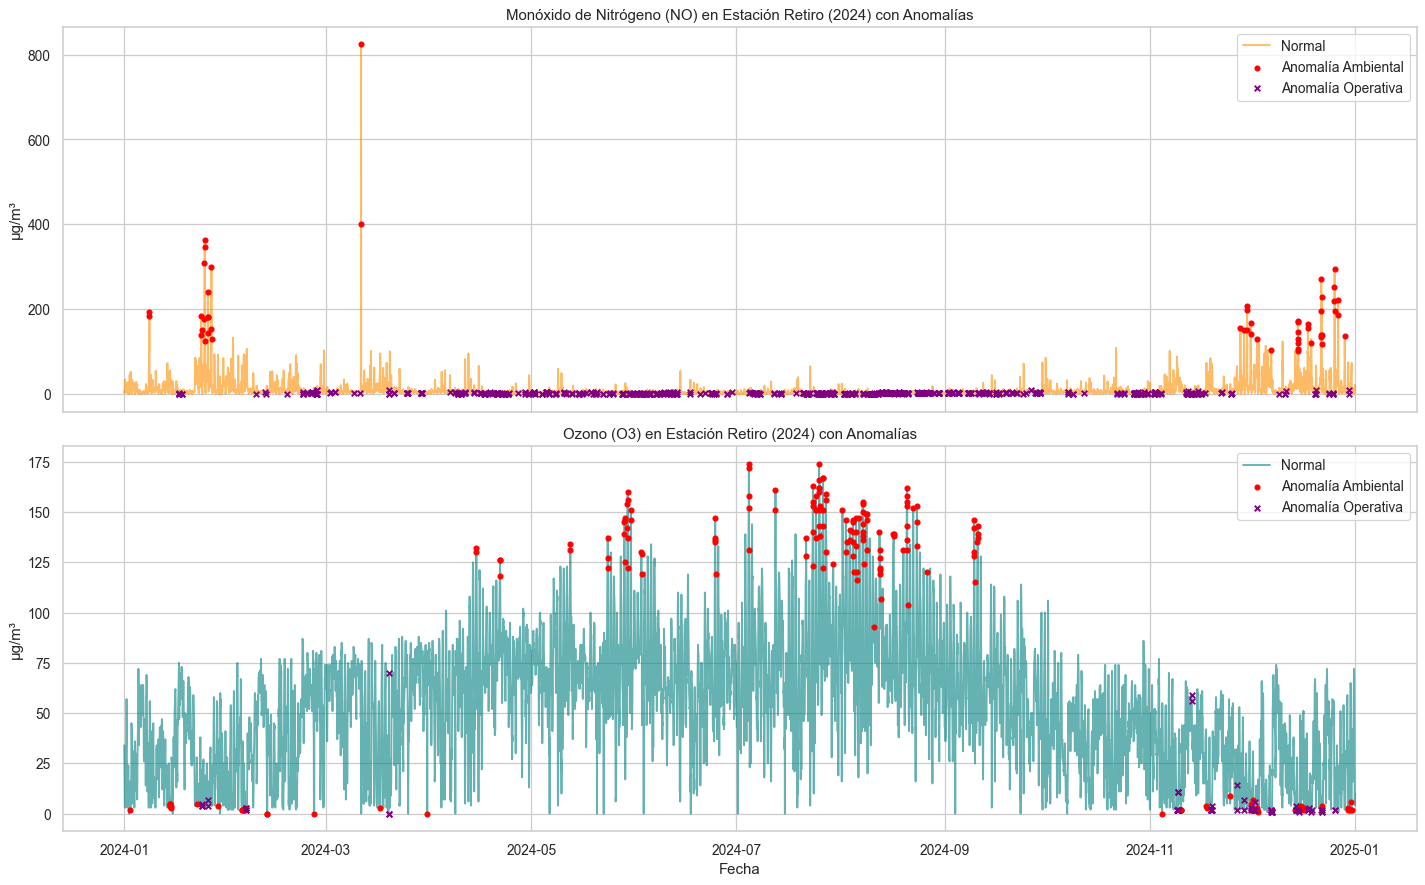

In [6]:
# Filtrar datos de la Estación 8
st8_no = df_largo[(df_largo['estacion'] == 8) & (df_largo['contaminante'] == 'NO') & (df_largo['ano'] == 2024)].copy().sort_values('fecha')
st8_o3 = df_largo[(df_largo['estacion'] == 8) & (df_largo['contaminante'] == 'O3') & (df_largo['ano'] == 2024)].copy().sort_values('fecha')

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Graficar NO
axes[0].plot(st8_no['fecha'], st8_no['valor'], label='Normal', color='darkorange', alpha=0.6)
anom_amb_no = st8_no[st8_no['anomalia_ambiental']]
anom_ope_no = st8_no[st8_no['anomalia_operativa']]
axes[0].scatter(anom_amb_no['fecha'], anom_amb_no['valor'], color='red', label='Anomalía Ambiental', zorder=5, s=15)
axes[0].scatter(anom_ope_no['fecha'], anom_ope_no['valor'], color='purple', marker='x', label='Anomalía Operativa', zorder=5, s=20)
axes[0].set_title('Monóxido de Nitrógeno (NO) en Estación Retiro (2024) con Anomalías', fontsize=12)
axes[0].set_ylabel('µg/m³')
axes[0].legend()

# Graficar O3
axes[1].plot(st8_o3['fecha'], st8_o3['valor'], label='Normal', color='teal', alpha=0.6)
anom_amb_o3 = st8_o3[st8_o3['anomalia_ambiental']]
anom_ope_o3 = st8_o3[st8_o3['anomalia_operativa']]
axes[1].scatter(anom_amb_o3['fecha'], anom_amb_o3['valor'], color='red', label='Anomalía Ambiental', zorder=5, s=15)
axes[1].scatter(anom_ope_o3['fecha'], anom_ope_o3['valor'], color='purple', marker='x', label='Anomalía Operativa', zorder=5, s=20)
axes[1].set_title('Ozono (O3) en Estación Retiro (2024) con Anomalías', fontsize=12)
axes[1].set_ylabel('µg/m³')
axes[1].set_xlabel('Fecha')
axes[1].legend()

plt.tight_layout()
plt.show()

### Relación NO vs O3 y Comportamiento de Anomalías

Graficamos un diagrama de dispersión entre ambos contaminantes alineados temporalmente. Como vimos en el EDA, existe una relación lineal inversa. Las anomalías marcadas por el modelo deberían corresponder a violaciones de este patrón.

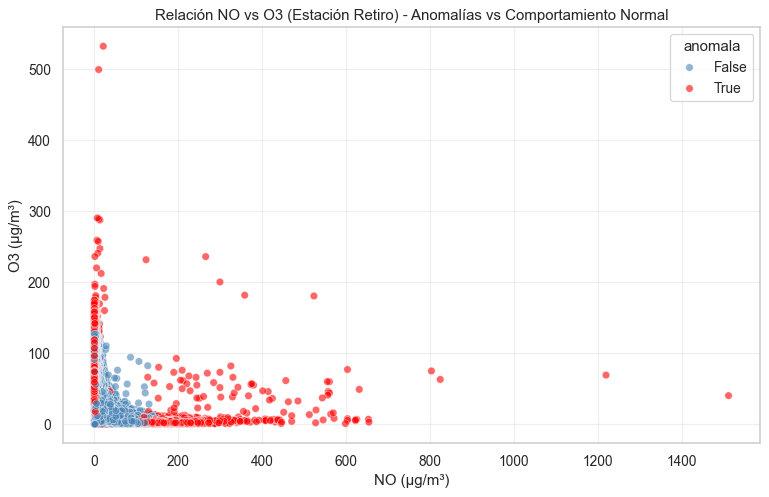

In [7]:
# Alinear NO y O3 en la Estación 8
st8_pivot = df_largo[df_largo['estacion'] == 8].pivot_table(
    index='fecha',
    columns='contaminante',
    values=['valor', 'anomalia_ambiental', 'anomalia_operativa']
)
# Aplanar nombres de columnas
st8_pivot.columns = [f'{col[0]}_{col[1]}' for col in st8_pivot.columns]
st8_pivot = st8_pivot.dropna()

# Definir estado conjunto de anomalía
st8_pivot['anomala'] = (
    st8_pivot['anomalia_ambiental_NO'].astype(bool) | 
    st8_pivot['anomalia_ambiental_O3'].astype(bool) | 
    st8_pivot['anomalia_operativa_NO'].astype(bool) | 
    st8_pivot['anomalia_operativa_O3'].astype(bool)
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=st8_pivot,
    x='valor_NO',
    y='valor_O3',
    hue='anomala',
    palette={True: 'red', False: 'steelblue'},
    alpha=0.6
)
plt.title('Relación NO vs O3 (Estación Retiro) - Anomalías vs Comportamiento Normal')
plt.xlabel('NO (µg/m³)')
plt.ylabel('O3 (µg/m³)')
plt.grid(alpha=0.3)
plt.show()

### Registros más anómalos (outliers extremos)

In [9]:
# Mostrar los 10 registros con menores scores de decisión en O3 y NO (indicativos de mayor grado de anomalía)
print("=== Top 5 registros más anómalos de NO ===")
print(df_largo[df_largo['contaminante'] == 'NO'].sort_values('score_anomalia')[['nombre_estacion', 'fecha', 'valor', 'residuo', 'score_anomalia']].head(5).to_string(index=False))

print("\n=== Top 5 registros más anómalos de O3 ===")
print(df_largo[df_largo['contaminante'] == 'O3'].sort_values('score_anomalia')[['nombre_estacion', 'fecha', 'valor', 'residuo', 'score_anomalia']].head(5).to_string(index=False))

=== Top 5 registros más anómalos de NO ===


KeyError: "['residuo'] not in index"